In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install cdsapi xarray netCDF4 rioxarray rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 88.6 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [ ]:
import os

BASE = "/content/drive/MyDrive/PyroRL_Saudi_Project/datasets"

folders = [
    "saudi_eastern_province/raw/era5/wind",
    "saudi_eastern_province/raw/era5/temperature",
    "saudi_eastern_province/raw/era5/humidity",

    "saudi_eastern_province/processed/wind",
    "saudi_eastern_province/processed/temperature",
    "saudi_eastern_province/processed/humidity",

    "saudi_eastern_province/grids/32x32",
    "saudi_eastern_province/grids/64x64",
]

for folder in folders:
    os.makedirs(os.path.join(BASE, folder), exist_ok=True)

print("ERA5 folders created.")

ERA5 folders created.


In [ ]:
%%writefile /root/.cdsapirc
url: https://cds.climate.copernicus.eu/api
key: e9b7a0af-311a-4edf-a94e-c580455fe680

Writing /root/.cdsapirc


In [ ]:
import cdsapi
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
SAUDI_BBOX = {
    "north": 29.5,
    "south": 24.0,
    "west": 47.0,
    "east": 52.5
}

In [ ]:
import cdsapi

dataset = "reanalysis-era5-single-levels"
request = {
    "product_type": ["reanalysis"],
    "variable": [
        "10m_u_component_of_wind",
        "10m_v_component_of_wind",
        "2m_dewpoint_temperature",
        "2m_temperature"
    ],
    "year": ["2025"],
    "month": ["06"],
    "day": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28", "29", "30"
    ],
    "time": [
        "00:00", "06:00", "12:00",
        "18:00"
    ],
    "data_format": "netcdf",
    "download_format": "unarchived",
    "area": [29.5, 47, 24, 52.5]
}

client = cdsapi.Client()
client.retrieve(dataset, request).download()


2026-06-10 13:38:21,982 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
INFO:ecmwf.datastores.legacy_client:[2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-

995ec14ad7c04ba858b8c9e151fa37a4.nc:   0%|          | 0.00/581k [00:00<?, ?B/s]

'995ec14ad7c04ba858b8c9e151fa37a4.nc'

In [ ]:
import shutil

SOURCE_FILE = "download.nc"

DEST_FILE = "/content/drive/MyDrive/PyroRL_Saudi_Project/datasets/saudi_eastern_province/raw/era5/era5_saudi_june_2025.nc"

shutil.move(SOURCE_FILE, DEST_FILE)

print("ERA5 file moved successfully.")

ERA5 file moved successfully.


In [ ]:
import xarray as xr

ds = xr.open_dataset(DEST_FILE)

ds

<xarray.Dataset> Size: 1MB
Dimensions:     (valid_time: 120, latitude: 23, longitude: 23)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 960B 2025-06-01 ... 2025-06-30T18...
    expver      (valid_time) <U4 2kB ...
  * latitude    (latitude) float64 184B 29.5 29.25 29.0 ... 24.5 24.25 24.0
  * longitude   (longitude) float64 184B 47.0 47.25 47.5 ... 52.0 52.25 52.5
    number      int64 8B ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 254kB ...
    v10         (valid_time, latitude, longitude) float32 254kB ...
    d2m         (valid_time, latitude, longitude) float32 254kB ...
    t2m         (valid_time, latitude, longitude) float32 254kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-10T13:39 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
print(ds.data_vars)

Data variables:
    u10      (valid_time, latitude, longitude) float32 254kB ...
    v10      (valid_time, latitude, longitude) float32 254kB ...
    d2m      (valid_time, latitude, longitude) float32 254kB ...
    t2m      (valid_time, latitude, longitude) float32 254kB ...


In [ ]:
print(ds.dims)

FrozenMappingWarningOnValuesAccess({'valid_time': 120, 'latitude': 23, 'longitude': 23})


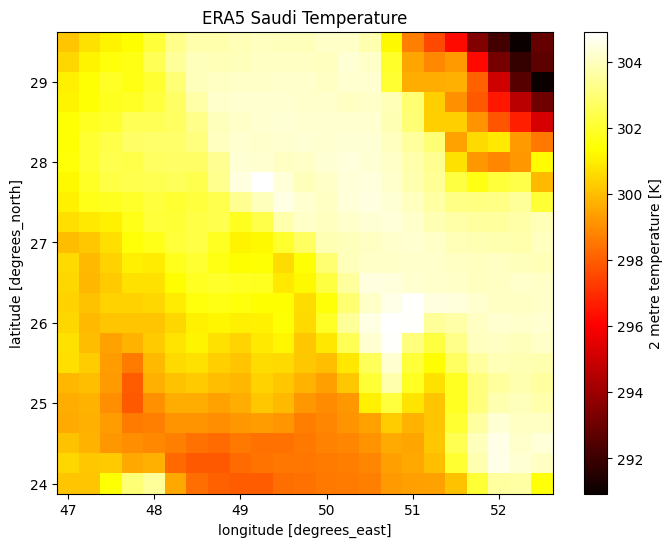

In [ ]:
import matplotlib.pyplot as plt

temp = ds['t2m'].isel(valid_time=0)

plt.figure(figsize=(8,6))

temp.plot(cmap='hot')

plt.title("ERA5 Saudi Temperature")

plt.show()

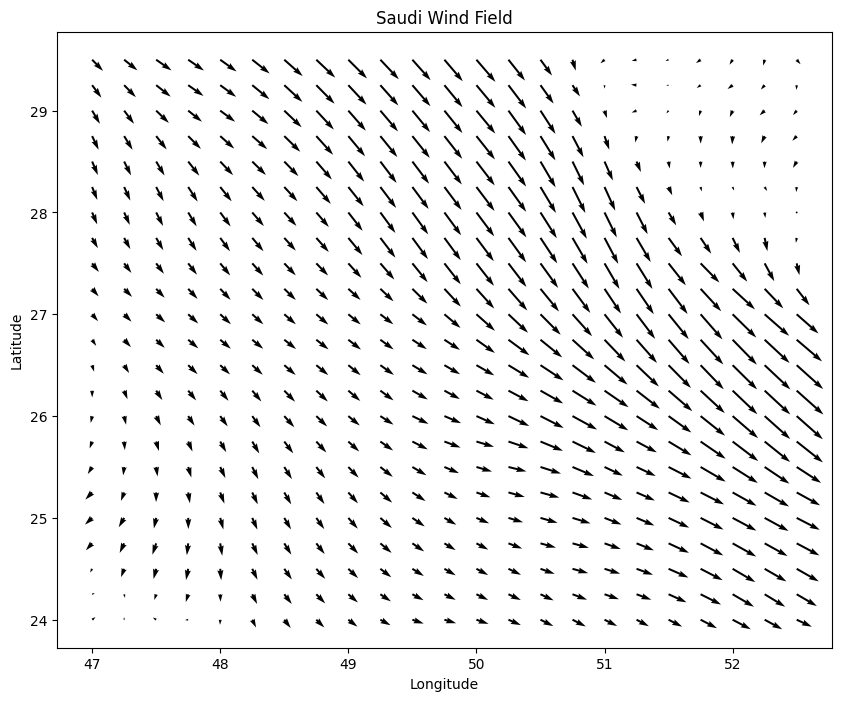

In [ ]:
u10 = ds['u10'].isel(valid_time=0)
v10 = ds['v10'].isel(valid_time=0)

plt.figure(figsize=(10,8))

plt.quiver(
    ds.longitude.values,
    ds.latitude.values,
    u10.values,
    v10.values
)

plt.title("Saudi Wind Field")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [ ]:
wind_x = ds['u10'].mean(dim='valid_time').values

wind_y = ds['v10'].mean(dim='valid_time').values

temperature = ds['t2m'].mean(dim='valid_time').values

dewpoint = ds['d2m'].mean(dim='valid_time').values

In [ ]:
temperature_c = temperature - 273.15

dewpoint_c = dewpoint - 273.15

In [ ]:
import numpy as np

humidity = 100 - 5 * (temperature_c - dewpoint_c)

humidity = np.clip(humidity, 0, 100)

In [ ]:
print("wind_x:", wind_x.shape)
print("wind_y:", wind_y.shape)
print("temperature:", temperature_c.shape)
print("humidity:", humidity.shape)

wind_x: (23, 23)
wind_y: (23, 23)
temperature: (23, 23)
humidity: (23, 23)


In [ ]:
def normalize(x):
    return (x - x.min()) / (x.max() - x.min())

In [ ]:
wind_x_norm = normalize(wind_x)

wind_y_norm = normalize(wind_y)

temp_norm = normalize(temperature_c)

humidity_norm = normalize(humidity)

In [ ]:
!pip install scikit-image

In [ ]:
from skimage.transform import resize

In [ ]:
GRID_32 = (32,32)
GRID_64 = (64,64)

wind_x_32 = resize(wind_x_norm, GRID_32)
wind_y_32 = resize(wind_y_norm, GRID_32)

temp_32 = resize(temp_norm, GRID_32)

humidity_32 = resize(humidity_norm, GRID_32)

wind_x_64 = resize(wind_x_norm, GRID_64)
wind_y_64 = resize(wind_y_norm, GRID_64)

temp_64 = resize(temp_norm, GRID_64)

humidity_64 = resize(humidity_norm, GRID_64)

In [ ]:
print(wind_x_32.shape)
print(temp_32.shape)

print(wind_x_64.shape)
print(temp_64.shape)

(32, 32)
(32, 32)
(64, 64)
(64, 64)


In [ ]:
import os

BASE = "/content/drive/MyDrive/PyroRL_Saudi_Project/datasets/saudi_eastern_province/grids"

os.makedirs(f"{BASE}/32x32", exist_ok=True)
os.makedirs(f"{BASE}/64x64", exist_ok=True)

In [ ]:
np.save(f"{BASE}/32x32/wind_x.npy", wind_x_32)

np.save(f"{BASE}/32x32/wind_y.npy", wind_y_32)

np.save(f"{BASE}/32x32/temperature.npy", temp_32)

np.save(f"{BASE}/32x32/humidity.npy", humidity_32)

print("32x32 saved.")

32x32 saved.


In [ ]:
np.save(f"{BASE}/64x64/wind_x.npy", wind_x_64)

np.save(f"{BASE}/64x64/wind_y.npy", wind_y_64)

np.save(f"{BASE}/64x64/temperature.npy", temp_64)

np.save(f"{BASE}/64x64/humidity.npy", humidity_64)

print("64x64 saved.")

64x64 saved.


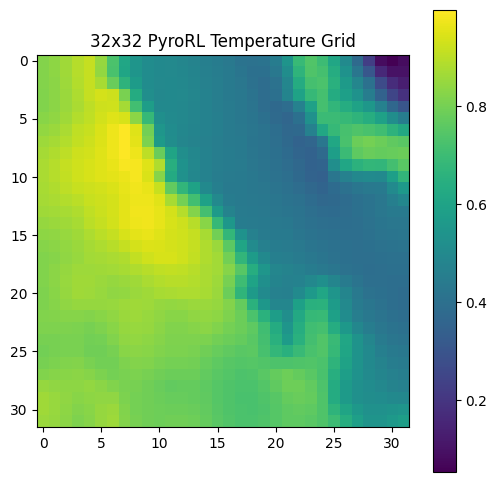

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(temp_32)

plt.title("32x32 PyroRL Temperature Grid")

plt.colorbar()

plt.show()

In [ ]:
import os

grid_path = "/content/drive/MyDrive/PyroRL_Saudi_Project/datasets/saudi_eastern_province/grids/32x32"

print(os.listdir(grid_path))

['wind_x.npy', 'wind_y.npy', 'temperature.npy', 'humidity.npy']


In [ ]:
import numpy as np

wind_x = np.load(f"{grid_path}/wind_x.npy")

print(wind_x.shape)

(32, 32)
